<a href="https://colab.research.google.com/github/hidarihizi/Trainee/blob/main/%E3%82%A4%E3%83%B3%E3%82%BF%E3%83%BC%E3%83%B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##------前処理
## CSVファイル名
df = pd.read_csv('stock_price.csv')
print(df.head(15))
## データ列の情報の確認
print(df.info())

##
df = df.rename(columns={'変化率 %':'変化率'})

##日付列の型の変換（Object→datetime）
df['日付'] = pd.to_datetime(df['日付'])
##出来高の型の変換(object→float)(Mは百万換算)
def dekidaka_change(a):
    if (a.endswith('M')):
        return float(a.replace('M',''))*1000000
    elif (a.endswith('B')):
        return float(a.replace('B',''))*1000000000

df['出来高'] = df['出来高'].apply(dekidaka_change,convert_dtype=True)
##変化率の変換
def henkaritu_change(a):
    if(a.endswith('%')):
        return float(a.replace('%',''))
    else:
        print("a")
        return float(a)

df['変化率'] = df['変化率'].apply(henkaritu_change,convert_dtype=True)

##確認
print(df.info())
##欠損地の有無の確認→今回は欠損値がないことが確認できた。
print(df.isnull().sum())



            日付     終値     始値     高値     安値      出来高   変化率 %
0   2025-12-30  157.7  158.9  158.9  157.7  131.30M  -0.57%
1   2025-12-29  158.6  159.0  159.1  157.5  143.79M  -0.13%
2   2025-12-26  158.8  157.4  158.9  157.2  152.24M   1.34%
3   2025-12-25  156.7  156.5  157.0  156.2   78.06M   0.26%
4   2025-12-24  156.3  156.0  156.3  155.3  101.92M   0.00%
5   2025-12-23  156.3  154.7  156.3  154.3  107.01M   1.03%
6   2025-12-22  154.7  157.3  157.6  154.7  159.51M  -1.46%
7   2025-12-19  157.0  157.0  157.4  156.3  227.27M   0.19%
8   2025-12-18  156.7  155.5  156.7  155.4  164.25M   1.16%
9   2025-12-17  154.9  154.5  155.0  153.8  147.06M  -0.13%
10  2025-12-16  155.1  155.0  155.7  154.2  163.05M  -0.19%
11  2025-12-15  155.4  155.8  156.2  155.1  152.41M  -0.06%
12  2025-12-12  155.5  155.1  155.7  154.7  226.86M   0.26%
13  2025-12-11  155.1  155.7  156.4  154.8  139.59M  -0.39%
14  2025-12-10  155.7  154.9  156.3  154.4  171.52M   1.24%
<class 'pandas.core.frame.DataFrame'>
Ra

/tmp/ipython-input-1938256190.py:25: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df['出来高'] = df['出来高'].apply(dekidaka_change,convert_dtype=True)
/tmp/ipython-input-1938256190.py:34: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df['変化率'] = df['変化率'].apply(henkaritu_change,convert_dtype=True)


In [3]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 75.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=9d642ed9a81d12828125438ee2edd482c4647f7e8ca11b5f9efc30c91ec9f647
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [7]:
#確認
df.tail()

,日付,終値,始値,高値,安値,出来高,変化率
3171,2013-01-10,37.1,36.9,37.1,36.9,246300000.0,0.82
3172,2013-01-09,36.8,37.0,37.1,36.8,297940000.0,-0.54
3173,2013-01-08,37.0,37.0,37.1,36.8,260770000.0,-0.27
3174,2013-01-07,37.1,37.3,37.4,37.0,317490000.0,0.54
3175,2013-01-04,36.9,37.0,37.0,36.6,363090000.0,1.65


**分析**



In [6]:
#2012年以降のデータを採用
df = df[df['日付']>'2013-01-01']

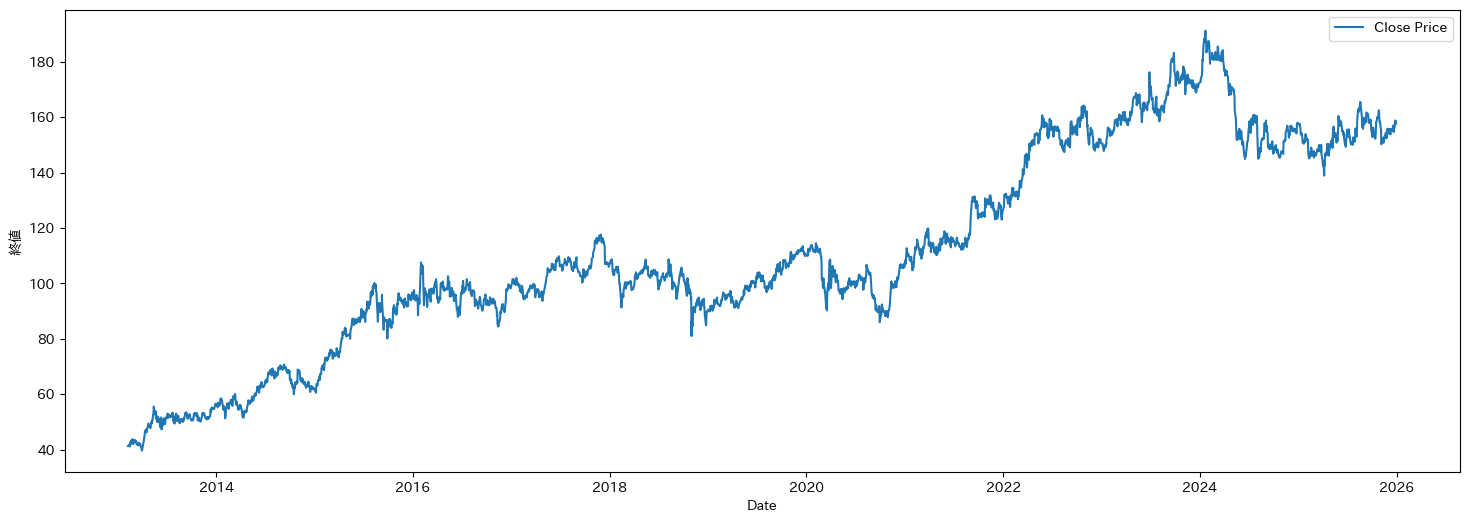

In [51]:
plt.figure(figsize=(18,6))
plt.plot(df['日付'],df['終値'],label = 'Close Price')
plt.xlabel('Date')
plt.ylabel('終値')
plt.legend()
plt.show()


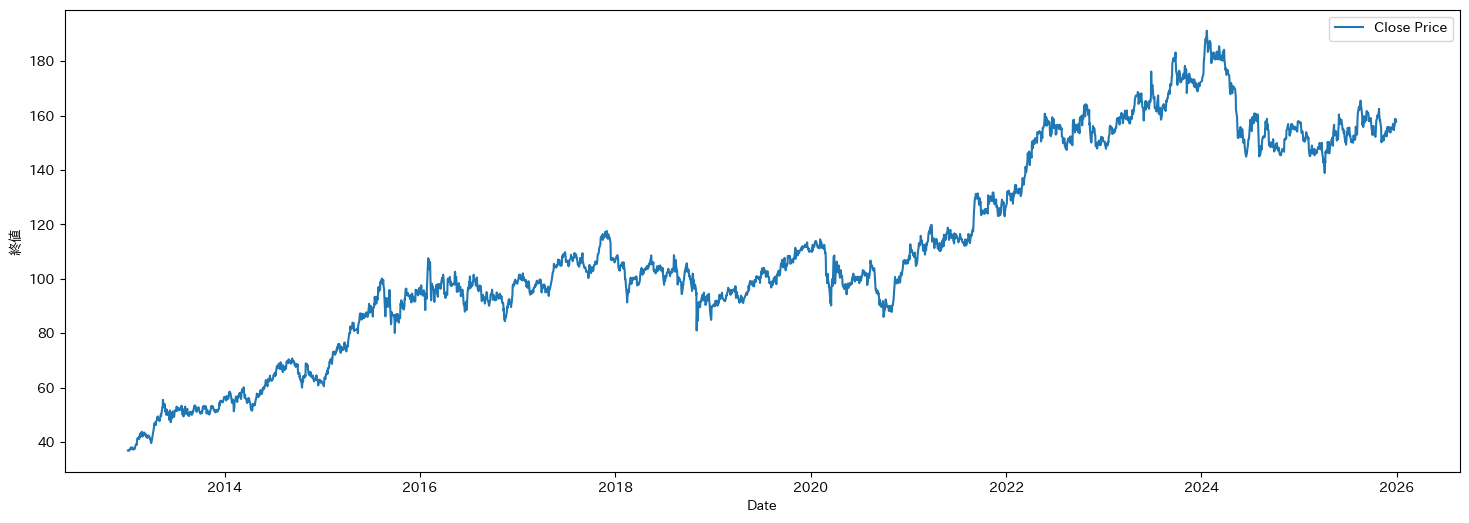

In [8]:
plt.figure(figsize=(18,6))
plt.plot(df['日付'],df['終値'],label = 'Close Price')
plt.xlabel('Date')
plt.ylabel('終値')
plt.legend()
plt.show()

In [50]:
import japanize_matplotlib

<Axes: >

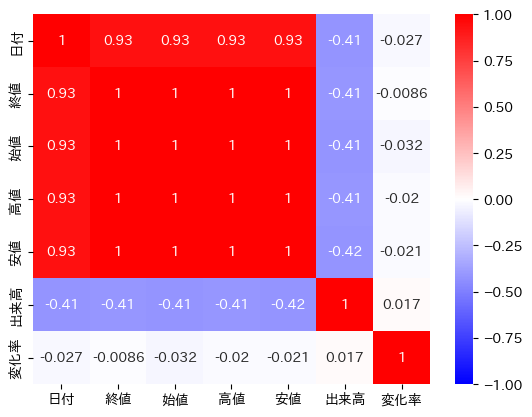

In [14]:
sns.heatmap(df.corr(),vmax=1,vmin=-1,annot=True,center = 0,cmap="bwr")

１．出来高は日付ごとに下降している</n>


２．出来高に対して、株価はいずれも負の相関がる。

In [15]:
##月の中で変動を見る
df['YearMonth'] = df['日付'].dt.to_period('M')

min_low_price_month = df.groupby('YearMonth')['安値'].idxmin()

min_low_price_day = df.loc[min_low_price_month,'日付'].dt.day
print(min_low_price_day)

day_count = min_low_price_day.value_counts().sort_index()

print(day_count)

3175     4
3156     1
3119    28
3116     2
3096     1
        ..
98       6
62      30
53      14
38       5
15       9
Name: 日付, Length: 156, dtype: int32
日付
1     18
2     10
3      3
4      9
5      6
6     10
7      6
8      4
9      7
10     5
11     2
12     3
13     3
14     4
15     3
16     2
17     4
18     4
19     4
20     2
22     5
23     1
24     3
25     4
26     2
27     3
28     5
29     5
30    12
31     7
Name: count, dtype: int64


月末と月初めになるのが多い

In [53]:
df['Day'] = df['日付'].dt.day
#出来高倍率
df['compare_dekidaka_15day'] = df['出来高'].rolling(window = 15).mean()
df['compare_dekidaka_the_day'] = df['出来高']/df['compare_dekidaka_15day']

In [17]:
#RSIの結果
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['終値'])

In [18]:
##乖離曲線
df["MA_25"] = df["終値"].rolling(window = 25).mean()
df['MA_Gap'] = (df['終値'] - df['MA_25']) / df['MA_25'] * 100

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3176 entries, 0 to 3175
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   日付                        3176 non-null   datetime64[ns]
 1   終値                        3176 non-null   float64       
 2   始値                        3176 non-null   float64       
 3   高値                        3176 non-null   float64       
 4   安値                        3176 non-null   float64       
 5   出来高                       3176 non-null   float64       
 6   変化率                       3176 non-null   float64       
 7   YearMonth                 3176 non-null   period[M]     
 8   Day                       3176 non-null   int32         
 9   compare_dekidaka_15day    3162 non-null   float64       
 10  compare_dekidaka_the_day  3162 non-null   float64       
 11  RSI                       3163 non-null   float64       
 12  MA_25                    

In [20]:
df.dropna()

,日付,終値,始値,高値,安値,出来高,変化率,YearMonth,Day,compare_dekidaka_15day,compare_dekidaka_the_day,RSI,MA_25,MA_Gap
24,2025-11-26,155.3,153.4,155.8,153.0,201590000.0,1.90,2025-11,26,1.573047e+08,1.281526,50.980392,155.752,-0.290205
25,2025-11-25,152.4,152.4,152.8,151.7,187110000.0,-1.17,2025-11,25,1.589087e+08,1.177469,38.281250,155.540,-2.018773
26,2025-11-21,154.2,152.7,154.2,152.7,217100000.0,1.05,2025-11,21,1.632213e+08,1.330096,45.517241,155.364,-0.749208
27,2025-11-20,152.6,152.9,153.3,152.4,143570000.0,0.07,2025-11,20,1.576687e+08,0.910580,42.038217,155.116,-1.622012
28,2025-11-19,152.5,152.1,153.3,152.0,158480000.0,-0.20,2025-11,19,1.589280e+08,0.997181,39.473684,154.948,-1.579885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,2013-01-10,37.1,36.9,37.1,36.9,246300000.0,0.82,2013-01,10,2.907453e+08,0.847133,35.714286,38.704,-4.144274
3172,2013-01-09,36.8,37.0,37.1,36.8,297940000.0,-0.54,2013-01,9,2.713127e+08,1.098143,38.461538,38.532,-4.494965
3173,2013-01-08,37.0,37.0,37.1,36.8,260770000.0,-0.27,2013-01,8,2.712967e+08,0.961199,44.736842,38.336,-3.484975
3174,2013-01-07,37.1,37.3,37.4,37.0,317490000.0,0.54,2013-01,7,2.734013e+08,1.161260,46.153846,38.152,-2.757391


In [60]:
df['Month_ID'] = df['日付'].dt.to_period('M')
df['Low_30%'] = df.groupby('Month_ID')['終値'].transform(lambda x: x.quantile(0.3))
df['Target'] = (df['終値'] <= df['Low_30%']).astype(int)

print("買い場の数（1） vs 待ちの数（0）:")
print(df['Target'].value_counts())

print(df[df['Target'] == 1][['日付', '終値', 'Low_30%', 'Target']].head())

買い場の数（1） vs 待ちの数（0）:
Target
0    2120
1    1032
Name: count, dtype: int64
             日付    終値  Low_30%  Target
3151 2013-02-08  41.3    41.88       1
3150 2013-02-12  41.5    41.88       1
3149 2013-02-13  41.7    41.88       1
3147 2013-02-15  41.1    41.88       1
3128 2013-03-14  41.8    41.90       1


In [66]:
train = df[df['日付']>'2023-01-01']
test = df[df['日付']<='2022-12-31']

features = ['Day', 'compare_dekidaka_the_day', 'RSI', 'MA_Gap']
target = 'Target'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(f"学習データの数: {len(X_train)}日分")
print(f"テストデータの数: {len(X_test)}日分")
print("準備完了！")

学習データの数: 734日分
テストデータの数: 2418日分
準備完了！


In [69]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report


model = lgb.LGBMClassifier(random_state=42, n_estimators=100, max_depth=5)

model.fit(X_train, y_train)
#予測
predictions = model.predict(X_test)

# 正解率の計算
accuracy = accuracy_score(y_test, predictions)
print(f"\n【テスト結果（2023年〜現在）】")
print(f"正解率: {accuracy * 100:.2f}%")
# precision（適中率）: 「買い」と言った日のうち、本当に正解だった割合
print("\n詳細レポート:")
print(classification_report(y_test, predictions))


【テスト結果（2023年〜現在）】
正解率: 73.04%

詳細レポート:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      1626
           1       0.63      0.44      0.52       792

    accuracy                           0.73      2418
   macro avg       0.69      0.66      0.67      2418
weighted avg       0.72      0.73      0.72      2418



<Figure size 1000x600 with 0 Axes>

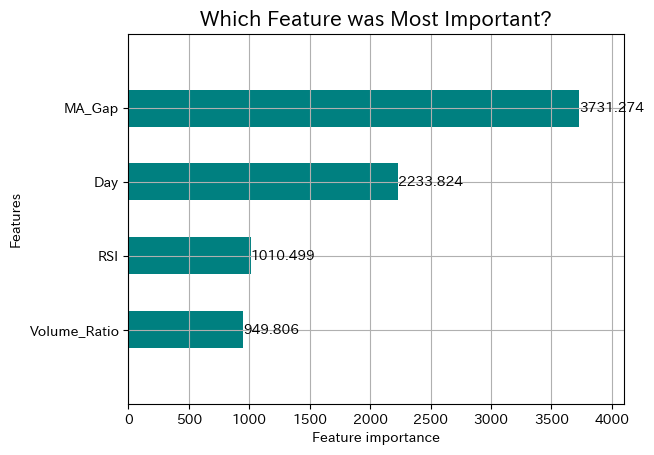

In [83]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=10, importance_type='gain', height=0.5, color='teal')
plt.title('Which Feature was Most Important?', fontsize=15)
plt.show()

In [85]:
result_df = test.copy()
result_df['AI_Pred'] = predictions

sato_prices = []
ai_prices = []

In [86]:
months = result_df['Month_ID'].unique()

wins = 0
losses = 0
draws = 0

for m in months:
    # その月のデータを取り出す
    monthly_data = result_df[result_df['Month_ID'] == m]

    # -----------------------------------
    # 1. 佐藤さんの買い方（25日）
    # -----------------------------------
    # 25日のデータを探す。もし25日が休日なら、その直後の営業日を買うことにする
    sato_buy = monthly_data[monthly_data['Day'] >= 25].head(1)

    if len(sato_buy) == 0:
        # 月末すぎて買えなかった場合は、最終日に買ったことにする
        sato_price = monthly_data.iloc[-1]['終値']
    else:
        sato_price = sato_buy['終値'].values[0]

    sato_prices.append(sato_price)

    # -----------------------------------
    # 2. AIの買い方（予測が1の日）
    # -----------------------------------
    # AIが「買い」と言った日を探す
    ai_signals = monthly_data[monthly_data['AI_Pred'] == 1]

    if len(ai_signals) > 0:
        # 買いサインが出た日の平均価格で買ったとする
        ai_price = ai_signals['終値'].mean()
    else:
        # もしAIが一度も「買い」と言わなかったら、佐藤さんと同じ日に買う（リスク回避）
        ai_price = sato_price

    ai_prices.append(ai_price)

    # -----------------------------------
    # 勝敗判定
    # -----------------------------------
    diff = sato_price - ai_price # プラスならAIの方が安く買えた（勝ち）

    if diff > 0:
        wins += 1
        # print(f"{m}月: AIの勝ち！ (佐藤: {sato_price:.1f}円 vs AI: {ai_price:.1f}円)")
    elif diff < 0:
        losses += 1
    else:
        draws += 1

# -----------------------------------------------------
# 10. 結果発表
# -----------------------------------------------------
avg_sato = sum(sato_prices) / len(sato_prices)
avg_ai = sum(ai_prices) / len(ai_prices)
improvement = avg_sato - avg_ai

print("-" * 40)
print(f"戦績: {wins}勝 {losses}敗 {draws}分")
print(f"勝率: {wins / len(months) * 100:.1f}%")
print("-" * 40)
print(f"佐藤さんの平均取得単価: {avg_sato:.2f} 円")
print(f"AIを使った平均取得単価: {avg_ai:.2f} 円")
print(f"結論: AIを使えば、1株あたり平均【 {improvement:.2f} 円 】安く買えます！")

----------------------------------------
戦績: 24勝 10敗 2分
勝率: 66.7%
----------------------------------------
佐藤さんの平均取得単価: 160.45 円
AIを使った平均取得単価: 158.70 円
結論: AIを使えば、1株あたり平均【 1.75 円 】安く買えます！


【通算成績 (36ヶ月)】
1株あたりのトータル利益: +63.1 円
もし毎回100株（1単元）買っていたら: +6,310 円 の得


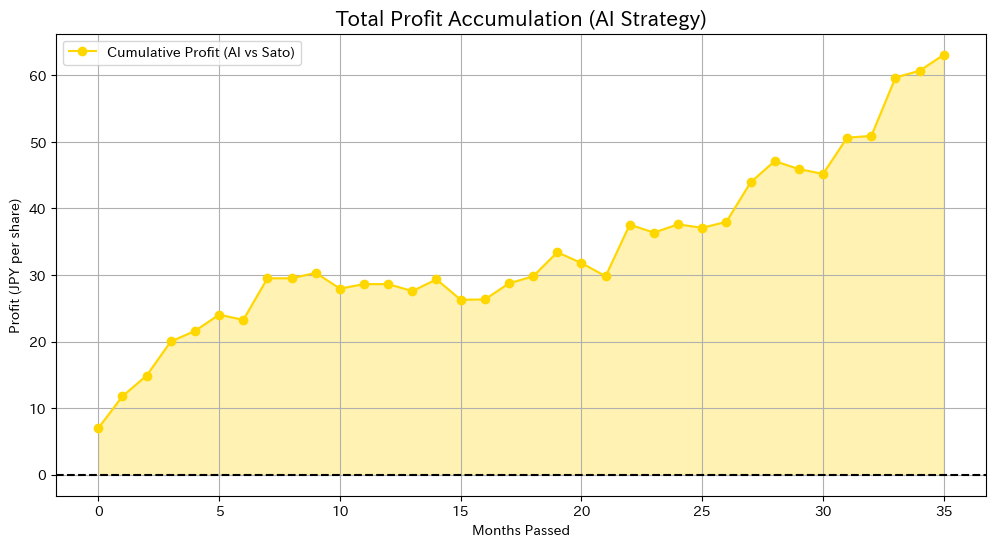

In [88]:
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 通算成績の計算と可視化
# -----------------------------------------------------

# これまでのリストをnumpy配列に変換して計算しやすくする
import numpy as np
sato_arr = np.array(sato_prices)
ai_arr = np.array(ai_prices)

# 毎月の「差額（AIの勝ち分）」を計算
diffs = sato_arr - ai_arr

# 累積和（Cumsum）を計算：勝ち分が積み上がっていく様子
cumulative_profit = np.cumsum(diffs)

# 結果表示
total_win = cumulative_profit[-1]
months_count = len(cumulative_profit)

print(f"【通算成績 ({months_count}ヶ月)】")
print(f"1株あたりのトータル利益: +{total_win:.1f} 円")
print(f"もし毎回100株（1単元）買っていたら: +{total_win * 100:,.0f} 円 の得")

# グラフ化
plt.figure(figsize=(12, 6))
plt.plot(cumulative_profit, marker='o', label='Cumulative Profit (AI vs Sato)', color='gold')
plt.title('Total Profit Accumulation (AI Strategy)', fontsize=15)
plt.xlabel('Months Passed')
plt.ylabel('Profit (JPY per share)')
plt.axhline(0, color='black', linestyle='--') # プラマイゼロライン
plt.fill_between(range(len(cumulative_profit)), 0, cumulative_profit, where=(cumulative_profit>0), color='gold', alpha=0.3)
plt.legend()
plt.grid()
plt.show()

In [76]:
pip install optuna

In [89]:
import optuna
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# -----------------------------------------------------
# Optunaによるハイパーパラメータチューニング
# -----------------------------------------------------

# 1. Optunaにやらせる「実験内容」を定義する関数
def objective(trial):
    # いろいろな設定値をサイコロで決める（探索範囲の定義）
    params = {
        'objective': 'binary',
        'metric': 'binary_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,

        # ここが調整する「つまみ」たち
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50)
    }

    # この設定でモデルを作る
    model = lgb.LGBMClassifier(**params)

    # 学習させる
    model.fit(X_train, y_train)

    # テストデータで予測する
    preds = model.predict(X_test)

    # 正解率を計算して返す（Optunaはこれを最大化しようと頑張る）
    accuracy = accuracy_score(y_test, preds)
    return accuracy

# -----------------------------------------------------
# 2. 実験開始！
# -----------------------------------------------------
print("チューニング開始...（AIが最適な設定を探しています）")

# direction='maximize' → 正解率を「最大化」することを目指す
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # 50回試行錯誤する

# -----------------------------------------------------
# 3. 結果発表
# -----------------------------------------------------
print("-" * 40)
print(f"発見された最強の正解率: {study.best_value * 100:.2f}%")
print("最強のパラメータ設定:")
print(study.best_params)
print("-" * 40)

# -----------------------------------------------------
# 4. 最強の設定でもう一度学習してモデルを更新
# -----------------------------------------------------
best_params = study.best_params
best_model = lgb.LGBMClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# 新しい精度を確認
new_preds = best_model.predict(X_test)
print("\n【チューニング後の最終精度】")
print(f"正解率: {accuracy_score(y_test, new_preds) * 100:.2f}%")

[I 2026-01-27 10:45:47,152] A new study created in memory with name: no-name-0237da4e-ca7e-42dc-9060-08b94c0de67c
[I 2026-01-27 10:45:47,337] Trial 0 finished with value: 0.7183622828784119 and parameters: {'num_leaves': 14, 'max_depth': 3, 'learning_rate': 0.257131871471202, 'n_estimators': 284, 'reg_alpha': 0.505111789727482, 'reg_lambda': 0.9334335063031137, 'min_child_samples': 16}. Best is trial 0 with value: 0.7183622828784119.


チューニング開始...（AIが最適な設定を探しています）


[I 2026-01-27 10:45:47,407] Trial 1 finished with value: 0.7125723738626965 and parameters: {'num_leaves': 38, 'max_depth': 5, 'learning_rate': 0.23940197665403934, 'n_estimators': 84, 'reg_alpha': 0.22393811077225945, 'reg_lambda': 0.5540977129114348, 'min_child_samples': 22}. Best is trial 0 with value: 0.7183622828784119.
[I 2026-01-27 10:45:47,484] Trial 2 finished with value: 0.7204301075268817 and parameters: {'num_leaves': 14, 'max_depth': 6, 'learning_rate': 0.2310890100702939, 'n_estimators': 81, 'reg_alpha': 0.875283718545477, 'reg_lambda': 0.48394588014811324, 'min_child_samples': 21}. Best is trial 2 with value: 0.7204301075268817.
[I 2026-01-27 10:45:47,619] Trial 3 finished with value: 0.7167080231596361 and parameters: {'num_leaves': 94, 'max_depth': 5, 'learning_rate': 0.12824599467260828, 'n_estimators': 212, 'reg_alpha': 0.2698930200019858, 'reg_lambda': 0.21655557441053463, 'min_child_samples': 49}. Best is trial 2 with value: 0.7204301075268817.
[I 2026-01-27 10:45:

----------------------------------------
発見された最強の正解率: 74.44%
最強のパラメータ設定:
{'num_leaves': 22, 'max_depth': 8, 'learning_rate': 0.011219619986288731, 'n_estimators': 280, 'reg_alpha': 0.5840449560243544, 'reg_lambda': 0.010249494230587075, 'min_child_samples': 43}
----------------------------------------

【チューニング後の最終精度】
正解率: 74.44%


In [78]:
# -----------------------------------------------------
# 10. 最終シミュレーション（チューニング後の最強AI）
# -----------------------------------------------------

# チューニング後の予測結果を使う
result_df = test.copy()
result_df['AI_Pred'] = new_preds  # ここがbest_modelの予測結果

sato_prices = []
ai_prices = []
months = result_df['Month_ID'].unique()

print(f"【魔改造AI vs 佐藤さん ({len(months)}ヶ月)】")
print("-" * 40)

wins = 0
losses = 0
draws = 0

for m in months:
    monthly_data = result_df[result_df['Month_ID'] == m]

    # 佐藤さん（25日）
    sato_buy = monthly_data[monthly_data['Day'] >= 25].head(1)
    if len(sato_buy) == 0:
        sato_price = monthly_data.iloc[-1]['終値']
    else:
        sato_price = sato_buy['終値'].values[0]
    sato_prices.append(sato_price)

    # 魔改造AI（予測が1の日）
    ai_signals = monthly_data[monthly_data['AI_Pred'] == 1]

    if len(ai_signals) > 0:
        ai_price = ai_signals['終値'].mean()
    else:
        ai_price = sato_price # AIが見送った月は佐藤さんと同じ動き

    ai_prices.append(ai_price)

    # 勝敗
    if sato_price > ai_price:
        wins += 1

# 集計
avg_sato = sum(sato_prices) / len(sato_prices)
avg_ai = sum(ai_prices) / len(ai_prices)
improvement = avg_sato - avg_ai

# 通算利益の計算（100株あたり）
total_profit_per_100shares = (sum(sato_prices) - sum(ai_prices)) * 100

print(f"勝率: {wins / len(months) * 100:.1f}%")
print(f"佐藤さんの平均取得単価: {avg_sato:.2f} 円")
print(f"魔改造AIの平均取得単価: {avg_ai:.2f} 円")
print("-" * 40)
print(f"【結論】")
print(f"1株あたりの改善幅: 平均 {improvement:.2f} 円 お得！")
print(f"もし100株ずつ積立していたら...: 合計 {total_profit_per_100shares:,.0f} 円 の利益上乗せ！")

【魔改造AI vs 佐藤さん (119ヶ月)】
----------------------------------------
勝率: 57.1%
佐藤さんの平均取得単価: 96.97 円
魔改造AIの平均取得単価: 95.41 円
----------------------------------------
【結論】
1株あたりの改善幅: 平均 1.57 円 お得！
もし100株ずつ積立していたら...: 合計 18,628 円 の利益上乗せ！


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3152 entries, 3151 to 0
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   日付                        3152 non-null   datetime64[ns]
 1   終値                        3152 non-null   float64       
 2   始値                        3152 non-null   float64       
 3   高値                        3152 non-null   float64       
 4   安値                        3152 non-null   float64       
 5   出来高                       3152 non-null   float64       
 6   変化率 %                     3152 non-null   object        
 7   Day                       3152 non-null   int32         
 8   Volume_Mean_15            3152 non-null   float64       
 9   Volume_Ratio              3152 non-null   float64       
 10  RSI                       3152 non-null   float64       
 11  MA_25                     3152 non-null   float64       
 12  MA_Gap                   

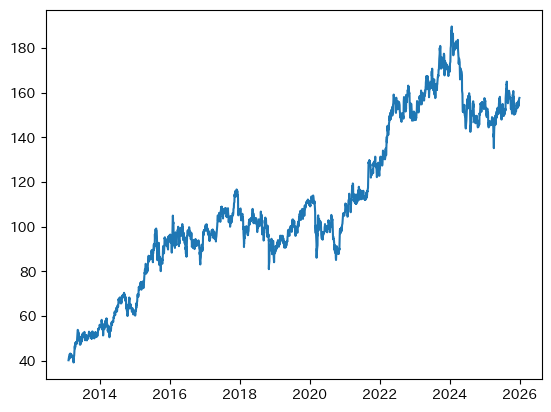

In [80]:
plt.plot(df['日付'],df['安値'])

グラフを描画します...


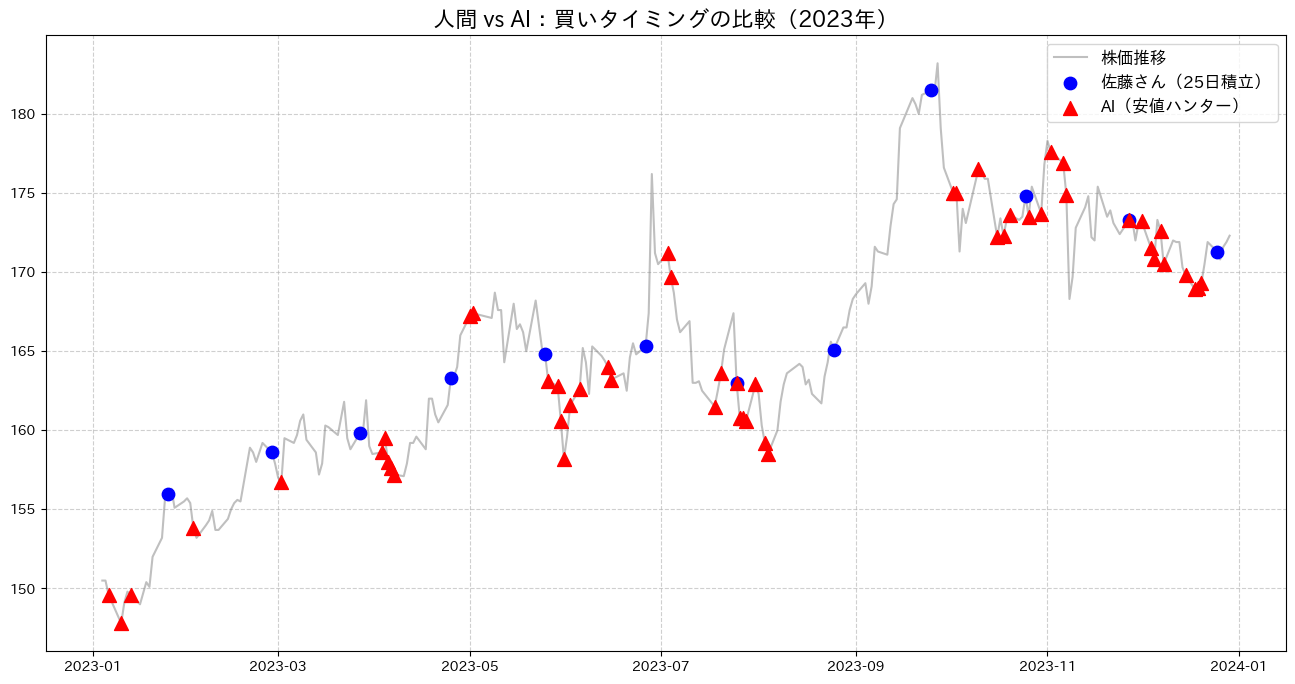

In [96]:


# -----------------------------------------------------
# 3. 可視化（本番）
# -----------------------------------------------------
print("グラフを描画します...")
plot_data = result_df[(result_df['日付'] >= '2023-01-01') & (result_df['日付'] <= '2023-12-31')].copy()

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(plot_data['日付'], plot_data['終値'], label='株価推移', color='gray', alpha=0.5, linewidth=1.5)

# 佐藤さん（青）
sato_buy = plot_data[plot_data['Day'] >= 25].groupby('Month_ID').first()
ax.scatter(sato_buy['日付'], sato_buy['終値'], color='blue', label='佐藤さん（25日積立）', s=80, zorder=5)

# AI（赤）
ai_buy = plot_data[plot_data['AI_Pred'] == 1]
ax.scatter(ai_buy['日付'], ai_buy['終値'], color='red', label='AI（安値ハンター）', s=100, marker='^', zorder=6)

ax.set_title('人間 vs AI：買いタイミングの比較（2023年）', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.show()

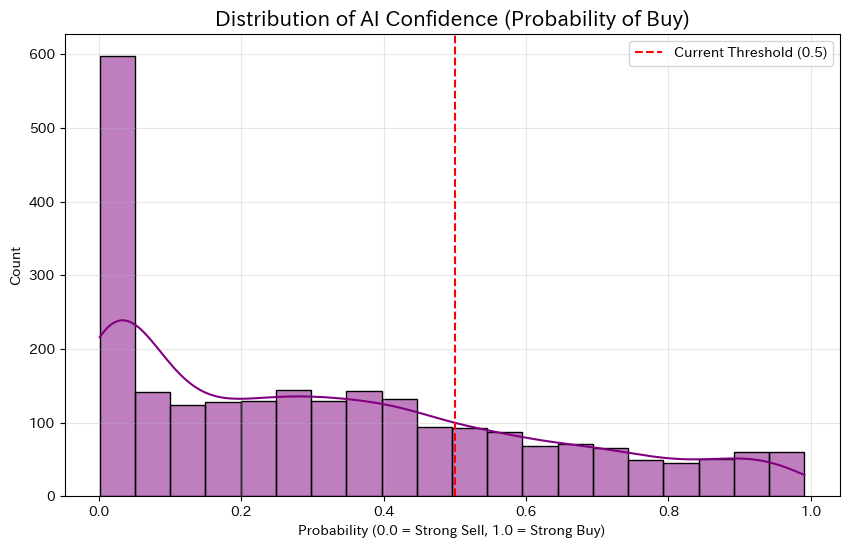

ValueError: Length of values (2418) does not match length of index (734)

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 12. 改善フェーズ：AIの「自信の度合い」を分析
# -----------------------------------------------------

# predict_proba() を使うと、「0の確率」と「1の確率」が出せます
# [:, 1] で「1（買い）である確率」だけを取り出します
y_pred_prob = model.predict_proba(X_test)[:, 1]

# ヒストグラムで分布を表示
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_prob, bins=20, kde=True, color='purple')
plt.title('Distribution of AI Confidence (Probability of Buy)', fontsize=15)
plt.xlabel('Probability (0.0 = Strong Sell, 1.0 = Strong Buy)')
plt.ylabel('Count')
plt.axvline(0.5, color='red', linestyle='--', label='Current Threshold (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 確率が高い順にデータを並べてみる
check_df = test.copy()
check_df['Probability'] = y_pred_prob
print("【AIが自信満々だった日トップ5】")
print(check_df[['日付', '終値', 'Probability', 'Target']].sort_values('Probability', ascending=False).head())

best
日付: 2023-01-10
購入株価: 147.8 円
その月の最安値との差: +0.00%
★AIの自信度: 58.3%
判定理由: RSI=43.8, 乖離率=-1.5%, 出来高倍率=1.8倍
worst
日付: 2024-05-02
購入株価: 170.4 円
その月の最安値との差: +12.25%
★AIの自信度: 58.3%
判定理由: RSI=36.6, 乖離率=-1.8%, 出来高倍率=0.7倍


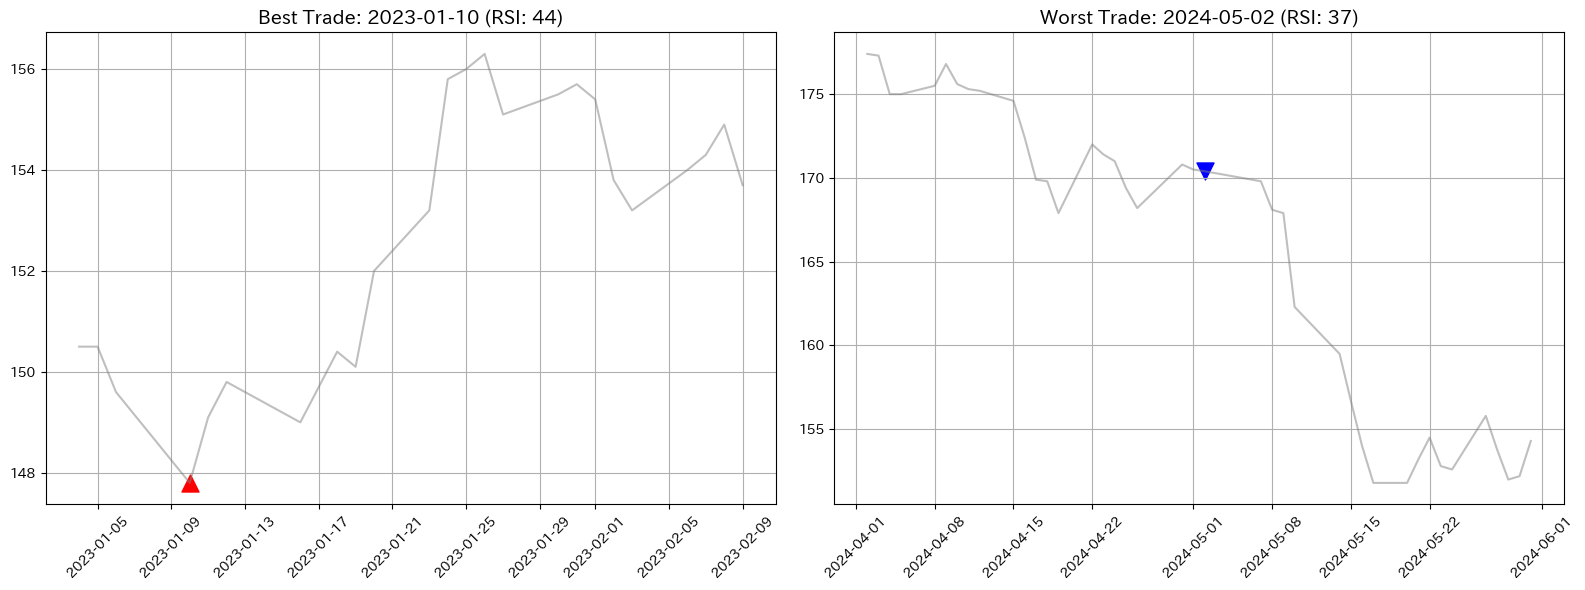

In [97]:
import matplotlib.pyplot as plt
import pandas as pd

X_target = result_df[['Day', 'Volume_Ratio', 'RSI', 'MA_Gap']]
result_df['Probability'] = model.predict_proba(X_target)[:, 1]

# -----------------------------------------------------
# 13. 結果の徹底分析（ベスト＆ワーストトレードの特定）
# -----------------------------------------------------

# 1. AIが買った日だけを抽出
ai_buys = result_df[result_df['AI_Pred'] == 1].copy()

# 2. その月の「最安値」と比べて、どれくらい安く買えたか？（安値乖離率）を計算
# 0%に近いほど「底値ドンピシャ」で買えたことになる
ai_buys['Month_Min'] = ai_buys.groupby('Month_ID')['終値'].transform('min')
ai_buys['Diff_from_Min'] = (ai_buys['終値'] - ai_buys['Month_Min']) / ai_buys['Month_Min'] * 100

# -----------------------------------------------------
# ベストプレー（神トレード）の分析
# -----------------------------------------------------
best_trade = ai_buys.sort_values('Diff_from_Min').iloc[0] # 一番底値に近かった日
print("best")
print(f"日付: {best_trade['日付'].date()}")
print(f"購入株価: {best_trade['終値']} 円")
print(f"その月の最安値との差: +{best_trade['Diff_from_Min']:.2f}%")
print(f"★AIの自信度: {best_trade['Probability']*100:.1f}%")
print(f"判定理由: RSI={best_trade['RSI']:.1f}, 乖離率={best_trade['MA_Gap']:.1f}%, 出来高倍率={best_trade['Volume_Ratio']:.1f}倍")

# -----------------------------------------------------
# ワーストプレー（失敗トレード）の分析
# -----------------------------------------------------
worst_trade = ai_buys.sort_values('Diff_from_Min', ascending=False).iloc[0] # 底値から一番遠かった日
print("worst")
print(f"日付: {worst_trade['日付'].date()}")
print(f"購入株価: {worst_trade['終値']} 円")
print(f"その月の最安値との差: +{worst_trade['Diff_from_Min']:.2f}%")
print(f"★AIの自信度: {best_trade['Probability']*100:.1f}%")
print(f"判定理由: RSI={worst_trade['RSI']:.1f}, 乖離率={worst_trade['MA_Gap']:.1f}%, 出来高倍率={worst_trade['Volume_Ratio']:.1f}倍")

# -----------------------------------------------------
# 拡大チャートで検証（前後1ヶ月を表示）
# -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ベストトレードの描画
target_date = best_trade['日付']
start = target_date - pd.DateOffset(days=30)
end = target_date + pd.DateOffset(days=30)
subset = result_df[(result_df['日付'] >= start) & (result_df['日付'] <= end)]

axes[0].plot(subset['日付'], subset['終値'], color='gray', alpha=0.5)
axes[0].scatter(target_date, best_trade['終値'], color='red', s=150, marker='^', label='AI Buy')
axes[0].set_title(f"Best Trade: {target_date.date()} (RSI: {best_trade['RSI']:.0f})", fontsize=14)
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=45)

# ワーストトレードの描画
target_date = worst_trade['日付']
start = target_date - pd.DateOffset(days=30)
end = target_date + pd.DateOffset(days=30)
subset = result_df[(result_df['日付'] >= start) & (result_df['日付'] <= end)]

axes[1].plot(subset['日付'], subset['終値'], color='gray', alpha=0.5)
axes[1].scatter(target_date, worst_trade['終値'], color='blue', s=150, marker='v', label='AI Buy (Fail)')
axes[1].set_title(f"Worst Trade: {target_date.date()} (RSI: {worst_trade['RSI']:.0f})", fontsize=14)
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

【🏆 AIのベストトレード（神エントリー）】
日付: 2023-01-10
購入株価: 147.8 円
底値との差: +0.00%
★AIの自信度: 58.3%
根拠: RSI=43.8, 乖離率=-1.5%

【💀 AIのワーストトレード（失敗）】
日付: 2024-05-02
購入株価: 170.4 円
底値との差: +12.25% （もっと下があった...）
★AIの自信度: 54.0%
根拠: RSI=36.6, 乖離率=-1.8%


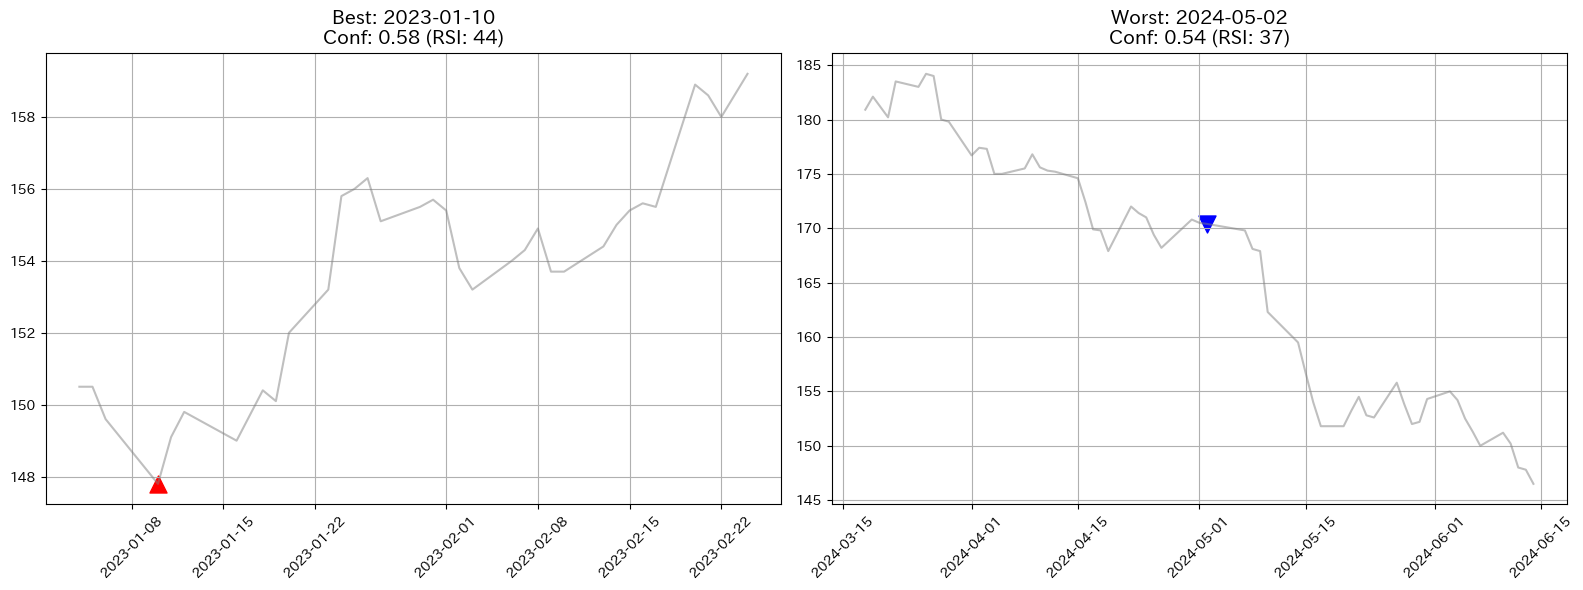

In [92]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------
# 修正：確率（Probability）を計算してデータに追加
# -----------------------------------------------------
# まだ計算していなければ計算して追加
# model.predict_proba() の 2列目（[:, 1]）が「買い(1)」の確率
if 'Probability' not in result_df.columns:
    # 予測に使った特徴量だけを渡す必要があります
    X_target = result_df[['Day', 'Volume_Ratio', 'RSI', 'MA_Gap']]
    result_df['Probability'] = model.predict_proba(X_target)[:, 1]

# -----------------------------------------------------
# 13. 結果の徹底分析（自信度 Probability を加味）
# -----------------------------------------------------

# 1. AIが「買い」と言った日だけ抽出
ai_buys = result_df[result_df['AI_Pred'] == 1].copy()

# 2. その月の「最安値」と比べて、どれくらい安く買えたか？（底値捕捉率）
# 0%に近いほど「底値ドンピシャ」
ai_buys['Month_Min'] = ai_buys.groupby('Month_ID')['終値'].transform('min')
ai_buys['Diff_from_Min'] = (ai_buys['終値'] - ai_buys['Month_Min']) / ai_buys['Month_Min'] * 100

# -----------------------------------------------------
# ベストプレー（神エントリー）の分析
# -----------------------------------------------------
# 底値との差が最も小さい日
best_trade = ai_buys.sort_values('Diff_from_Min').iloc[0]

print("【🏆 AIのベストトレード（神エントリー）】")
print(f"日付: {best_trade['日付'].date()}")
print(f"購入株価: {best_trade['終値']} 円")
print(f"底値との差: +{best_trade['Diff_from_Min']:.2f}%")
print(f"★AIの自信度: {best_trade['Probability']*100:.1f}%")  # ここが重要！
print(f"根拠: RSI={best_trade['RSI']:.1f}, 乖離率={best_trade['MA_Gap']:.1f}%")

# -----------------------------------------------------
# ワーストプレー（高値掴み）の分析
# -----------------------------------------------------
# 底値との差が最も大きい（＝高値で掴んでしまった）日
worst_trade = ai_buys.sort_values('Diff_from_Min', ascending=False).iloc[0]

print("\n【💀 AIのワーストトレード（失敗）】")
print(f"日付: {worst_trade['日付'].date()}")
print(f"購入株価: {worst_trade['終値']} 円")
print(f"底値との差: +{worst_trade['Diff_from_Min']:.2f}% （もっと下があった...）")
print(f"★AIの自信度: {worst_trade['Probability']*100:.1f}%") # ここに注目！
print(f"根拠: RSI={worst_trade['RSI']:.1f}, 乖離率={worst_trade['MA_Gap']:.1f}%")


# -----------------------------------------------------
# チャートで比較（ビジュアル分析）
# -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ベストトレード
target_date = best_trade['日付']
start = target_date - pd.DateOffset(days=45)
end = target_date + pd.DateOffset(days=45)
subset = result_df[(result_df['日付'] >= start) & (result_df['日付'] <= end)]

axes[0].plot(subset['日付'], subset['終値'], color='gray', alpha=0.5)
axes[0].scatter(target_date, best_trade['終値'], color='red', s=150, marker='^', label='AI Buy')
axes[0].set_title(f"Best: {target_date.date()}\nConf: {best_trade['Probability']:.2f} (RSI: {best_trade['RSI']:.0f})", fontsize=14, fontweight='bold')
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=45)

# ワーストトレード
target_date = worst_trade['日付']
start = target_date - pd.DateOffset(days=45)
end = target_date + pd.DateOffset(days=45)
subset = result_df[(result_df['日付'] >= start) & (result_df['日付'] <= end)]

axes[1].plot(subset['日付'], subset['終値'], color='gray', alpha=0.5)
axes[1].scatter(target_date, worst_trade['終値'], color='blue', s=150, marker='v', label='AI Buy (Fail)')
axes[1].set_title(f"Worst: {target_date.date()}\nConf: {worst_trade['Probability']:.2f} (RSI: {worst_trade['RSI']:.0f})", fontsize=14, fontweight='bold')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

【閾値ごとのパフォーマンス比較】
閾値     | 取引回数  | 勝率     | 平均リターン(円) 
--------------------------------------------------
0.50   | 222       | 55.0%   | +1.86 円
0.52   | 207       | 56.5%   | +1.86 円
0.54   | 189       | 57.7%   | +1.95 円
0.55   | 180       | 57.8%   | +1.97 円
0.56   | 174       | 58.0%   | +1.95 円
0.58   | 158       | 59.5%   | +2.09 円
0.60   | 147       | 60.5%   | +2.12 円
0.62   | 131       | 62.6%   | +2.22 円
0.64   | 118       | 66.1%   | +2.45 円
0.66   | 100       | 66.0%   | +2.25 円


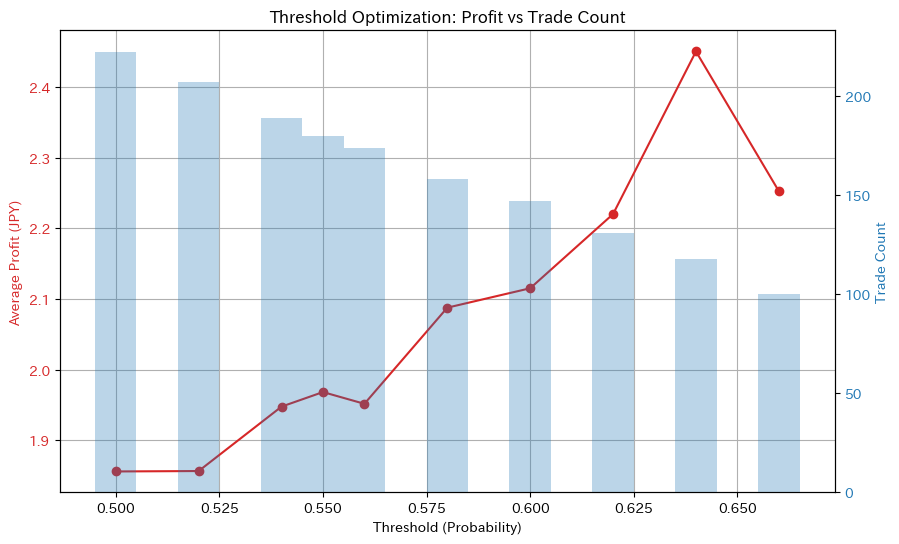

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 15. 「黄金の閾値」を探す実験
# -----------------------------------------------------


thresholds = [0.50, 0.52, 0.54, 0.55, 0.56, 0.58, 0.60,0.62,0.64,0.66]

results = []

print(f"【閾値ごとのパフォーマンス比較】")
print(f"{'閾値':<6} | {'取引回数':<5} | {'勝率':<6} | {'平均リターン(円)':<10}")
print("-" * 50)

for th in thresholds:
    # 閾値以上のときだけ「買い(1)」にする
    # Probability列がない場合は作成したコードを実行してください
    if 'Probability' not in result_df.columns:
        # Probability計算用の緊急対応（もし列がなかったら）
        X_target = result_df[['Day', 'Volume_Ratio', 'RSI', 'MA_Gap']]
        result_df['Probability'] = model.predict_proba(X_target)[:, 1]

    # AIの判断を書き換え
    custom_pred = (result_df['Probability'] >= th).astype(int)

    # その条件で買った日のデータを抽出
    buys = result_df[custom_pred == 1]

    if len(buys) == 0:
        continue # 取引ゼロならスキップ

    # 勝率（安値圏で買えた割合）
    win_rate = buys['Target'].mean()

    # 利益シミュレーション（佐藤さん価格との差）
    # ※ 簡易計算：その月の平均購入単価 vs 佐藤さんの25日買い
    profit_sum = 0
    months = buys['Month_ID'].unique()

    for m in months:
        # AIの平均取得単価
        ai_p = buys[buys['Month_ID'] == m]['終値'].mean()
        # 佐藤さんの取得単価
        sato_data = result_df[(result_df['Month_ID'] == m) & (result_df['Day'] >= 25)]
        if len(sato_data) > 0:
            sato_p = sato_data.iloc[0]['終値']
        else:
            sato_p = result_df[result_df['Month_ID'] == m].iloc[-1]['終値']

        profit_sum += (sato_p - ai_p) # プラスならAIの勝ち

    avg_profit = profit_sum / len(months)

    # 結果を保存
    results.append({'threshold': th, 'count': len(buys), 'win_rate': win_rate, 'profit': avg_profit})

    print(f"{th:.2f}   | {len(buys):<9} | {win_rate*100:.1f}%   | +{avg_profit:.2f} 円")

# -----------------------------------------------------
# 結果をグラフ化
# -----------------------------------------------------
df_res = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Threshold (Probability)')
ax1.set_ylabel('Average Profit (JPY)', color=color)
ax1.plot(df_res['threshold'], df_res['profit'], marker='o', color=color, label='Profit')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Trade Count', color=color)
ax2.bar(df_res['threshold'], df_res['count'], alpha=0.3, width=0.01, color=color, label='Count')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Threshold Optimization: Profit vs Trade Count')
plt.show()

In [102]:
import pandas as pd
import numpy as np

# -----------------------------------------------------
# 16. 最終決定：0.56〜0.58を精密スキャン
# -----------------------------------------------------

# 調査する範囲（0.56から0.58まで、0.005刻み）
# 0.56, 0.565, 0.57, 0.575, 0.58
choice = [0.6375,0.64,0.6425]

results = []



# result_df に Probability が入っている前提（fine_modelの結果）
for th in choice:
    # 閾値以上のときだけ「買い(1)」にする
    # ※もし前のコードで変数名が fine_result だった場合はそちらを使ってください
    target_df = result_df if 'Probability' in result_df.columns else fine_result

    custom_pred = (target_df['Probability'] >= th).astype(int)

    buys = target_df[custom_pred == 1]

    if len(buys) == 0:
        continue

    # 勝率（Target=1 の割合）
    win_rate = buys['Target'].mean()

    # 利益シミュレーション
    profit_sum = 0
    months = buys['Month_ID'].unique()

    for m in months:
        ai_p = buys[buys['Month_ID'] == m]['終値'].mean()
        # 佐藤さんのデータ（25日買い）
        sato_data = target_df[(target_df['Month_ID'] == m) & (target_df['Day'] >= 25)]
        if len(sato_data) > 0:
            sato_p = sato_data.iloc[0]['終値']
        else:
            sato_p = target_df[target_df['Month_ID'] == m].iloc[-1]['終値']
        profit_sum += (sato_p - ai_p)

    avg_profit = profit_sum / len(months)
    results.append({'threshold': th, 'count': len(buys), 'win_rate': win_rate, 'profit': avg_profit})

    print(f"{th:.3f}  | {len(buys):<9} | {win_rate*100:.1f}%   | +{avg_profit:.2f} 円")

# ベストを探す
if len(results) > 0:
    best_res = sorted(results, key=lambda x: x['profit'], reverse=True)[0]
    print("-" * 50)
    print(f"🏆 決定！最も儲かる閾値は... 【 {best_res['threshold']:.3f} 】 です！")
    print(f"その時の利益: +{best_res['profit']:.2f} 円")
    print(f"（取引回数: {best_res['count']}回, 勝率: {best_res['win_rate']*100:.1f}%）")
else:
    print("条件に合う取引がありませんでした。")

0.637  | 120       | 65.8%   | +2.44 円
0.640  | 118       | 66.1%   | +2.45 円
0.642  | 115       | 66.1%   | +2.40 円
--------------------------------------------------
🏆 決定！最も儲かる閾値は... 【 0.640 】 です！
その時の利益: +2.45 円
（取引回数: 118回, 勝率: 66.1%）


In [114]:
import pandas as pd


confidence = 0.64

# Probabilityがない場合は計算（念のため）
if 'Probability' not in result_df.columns:
    X_target = result_df[['Day', 'Volume_Ratio', 'RSI', 'MA_Gap']]
    result_df['Probability'] = model.predict_proba(X_target)[:, 1]

# 最終的な売買判断を下す
final_pred = (result_df['Probability'] >= confidence).astype(int)
result_df['Final_Decision'] = final_pred

# エントリーした日だけを抽出
final_buys = result_df[result_df['Final_Decision'] == 1]


if len(final_buys) == 0:
    print("取引回数が0回になってしまいました。")
else:
    # 1. 勝率（安値圏で買えた割合）
    win_rate = final_buys['Target'].mean()

    # 2. 利益シミュレーション
    profit_sum = 0
    months = final_buys['Month_ID'].unique()

    for m in months:
        ai_p = final_buys[final_buys['Month_ID'] == m]['終値'].mean()
        # 佐藤さん（25日）
        sato_data = result_df[(result_df['Month_ID'] == m) & (result_df['Day'] >= 25)]
        if len(sato_data) > 0:
            sato_p = sato_data.iloc[0]['終値']
        else:
            sato_p = result_df[result_df['Month_ID'] == m].iloc[-1]['終値']
        profit_sum += (sato_p - ai_p)

    avg_profit = profit_sum / len(months)

    # 年間換算（1ヶ月あたりの利益 × 12）
    yearly_profit_100shares = avg_profit * 100 * 12

    print(f"■ 取引データ")
    print(f"  - 取引回数: {len(final_buys)} 回")
    print(f"  - 勝率: {win_rate * 100:.1f} %")
    print(f"\n■ 収支インパクト")
    print(f"  - 1株あたりの改善幅: 平均 +{avg_profit:.2f} 円")
    print(f"  - 100株積立時の年間メリット: 約 +{yearly_profit_100shares:,.0f} 円")


■ 取引データ
  - 取引回数: 118 回
  - 勝率: 66.1 %

■ 収支インパクト
  - 1株あたりの改善幅: 平均 +2.45 円
  - 100株積立時の年間メリット: 約 +2,941 円


In [106]:
import lightgbm as lgb

# 1. モデルの定義（解像度重視の設定）
final_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=-1,
    num_leaves=31,       # 複雑なパターン認識を許可
    min_child_samples=10 # データが少なくても敏感に反応させる
)

# 2. 学習（過去のデータで特訓）
# X_train: 特徴量（RSI, MA_Gap, Volume_Ratio, Day）
# y_train: 正解（安値圏なら1, それ以外は0）
final_model.fit(X_train, y_train)

# 3. 予測（確率を出させる）
# テスト期間のデータに対して「自信度（確率）」を計算
probs = final_model.predict_proba(X_test)[:, 1]

# 4. 厳選エントリー（閾値 0.65）
# 確率が65%以上の時だけ「買い(1)」と判定する
final_decision = (probs >= 0.65).astype(int)

